In [1]:
import copy
import torch
import numpy as np
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from graph_datasets import GraphDataset
from graph_attention import CrossAttention
from performer_pytorch import NaiveAttention, FastAttention

/Users/aidandaly/miniforge3/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/aidandaly/miniforge3/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/Users/aidandaly/miniforge3/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [15]:
edge_index = torch.tensor([[0,1],
                           [1,0],
                           [1,2],
                           [2,1]], dtype=torch.long)

n_nodes = 3
n_tokens = 10
token_dim = 6
x = torch.tensor(np.random.uniform(0,1,size=(n_nodes, n_tokens, token_dim)), dtype=torch.float)
graph = Data(x=x, edge_index=edge_index.t().contiguous())

data = GraphDataset([graph])
loader = DataLoader(data, batch_size=1)

In [16]:
gca = CrossAttention(dim=token_dim, heads=2, dim_head=16, fast_attention=True)

In [17]:
batch = next(iter(loader))
out, attn = gca(batch.x, batch.edge_index, output_attentions=True)

print(out.shape)
print(attn.shape)

out2 = gca(batch.x, batch.edge_index)

assert(torch.equal(out, out2))

out

torch.Size([4, 2, 10, 16]) torch.Size([4, 10, 10])
torch.Size([3, 10, 6])
torch.Size([3, 10, 10])


tensor([[[-0.1151, -0.1720, -0.0133, -0.2118,  0.2474,  0.0856],
         [-0.1133, -0.1689, -0.0155, -0.2116,  0.2475,  0.0879],
         [-0.1142, -0.1670, -0.0137, -0.2110,  0.2498,  0.0914],
         [-0.1130, -0.1713, -0.0147, -0.2105,  0.2465,  0.0858],
         [-0.1136, -0.1716, -0.0145, -0.2110,  0.2470,  0.0861],
         [-0.1135, -0.1716, -0.0158, -0.2103,  0.2471,  0.0867],
         [-0.1134, -0.1705, -0.0153, -0.2095,  0.2476,  0.0879],
         [-0.1134, -0.1705, -0.0139, -0.2107,  0.2470,  0.0869],
         [-0.1126, -0.1682, -0.0152, -0.2113,  0.2470,  0.0871],
         [-0.1132, -0.1699, -0.0161, -0.2100,  0.2474,  0.0878]],

        [[-0.0966, -0.1541, -0.0217, -0.1891,  0.2352,  0.1010],
         [-0.0952, -0.1536, -0.0217, -0.1886,  0.2355,  0.1003],
         [-0.0966, -0.1544, -0.0225, -0.1878,  0.2340,  0.0995],
         [-0.0960, -0.1524, -0.0217, -0.1872,  0.2357,  0.1010],
         [-0.0952, -0.1525, -0.0231, -0.1868,  0.2350,  0.0986],
         [-0.0953, -0.1

In [19]:
attn.shape

torch.Size([3, 10, 10])

### To verify that cross-attention is working:
- Three nodes configured in a line:  {0}--{1}--{2}
- Manually compute K, Q, V matrices for each node
- Assert:
  - H_0 = Attention(Q_0, K_1, V_1)
  - H_1 = (Attention(Q_1, K_0, V_0) + Attention(Q_1, K_2, V_2)) / 2
  - H_2 = Attention(Q_2, K_1, V_1)

In [10]:
n_nodes = 3
n_tokens = 4
token_dim = 2

edge_index = torch.tensor([[0,1],
                           [1,0],
                           [1,2],
                           [2,1]], dtype=torch.long)

x = torch.tensor([[[0,1],
                   [1,1],
                   [1,0],
                   [0,1]],
                  [[-1,-1],
                   [0,-2],
                   [-1,0],
                   [-.5,-.5]],
                  [[.4,.4],
                   [.2,.2],
                   [.1,.1],
                   [.1,.4]]])
graph = Data(x=x, edge_index=edge_index.t().contiguous())

data = GraphDataset([graph])
loader = DataLoader(data, batch_size=1)

In [11]:
gca = CrossAttention(dim=token_dim, heads=1, dim_head=2, fast_attention=False)
gca.eval()

CrossAttention()

In [12]:
batch = next(iter(loader))
out, attn_wts = gca(batch.x, batch.edge_index, output_attentions=True)
out

torch.Size([4, 1, 4, 2]) torch.Size([4, 4, 4])


tensor([[[ 0.0727, -0.6805],
         [ 0.0306, -0.6612],
         [ 0.0446, -0.6659],
         [ 0.0727, -0.6805]],

        [[-0.6478, -0.6533],
         [-0.6523, -0.6489],
         [-0.6519, -0.6538],
         [-0.6542, -0.6516]],

        [[ 0.0641, -0.6755],
         [ 0.0757, -0.6805],
         [ 0.0816, -0.6831],
         [ 0.0771, -0.6816]]], grad_fn=<AddBackward0>)

In [13]:
attn_wts.shape

torch.Size([3, 4, 4])

In [14]:
attention = NaiveAttention()

q0, q1, q2 = gca.to_q(x[0]), gca.to_q(x[1]), gca.to_q(x[2])
k0, k1, k2 = gca.to_k(x[0]), gca.to_k(x[1]), gca.to_k(x[2])
v0, v1, v2 = gca.to_v(x[0]), gca.to_v(x[1]), gca.to_v(x[2])

a0 = attention(q0, k1, v1)
a1 = (attention(q1, k0, v0) + attention(q1, k2, v2)) / 2
a2 = attention(q2, k1, v1)

assert torch.equal(gca.to_out(a0), out[0])
assert torch.equal(gca.to_out(a1), out[1])
assert torch.equal(gca.to_out(a2), out[2])

### Test attention routing through a GraphSequence

In [6]:
import seaborn as sns
from graph_attention import GraphPerformer
from matplotlib import pyplot as plt

In [3]:
edge_index = torch.tensor([[0,1],
                           [1,0],
                           [1,2],
                           [2,1]], dtype=torch.long)

n_nodes = 3
n_tokens = 10
token_dim = 6
x = torch.tensor(np.random.uniform(0,1,size=(n_nodes, n_tokens, token_dim)), dtype=torch.float)
graph = Data(x=x, edge_index=edge_index.t().contiguous())

data = GraphDataset([graph])
loader = DataLoader(data, batch_size=1)

In [4]:
gp = GraphPerformer(
    dim=token_dim,
    depth=6,       # number of attention layers (pairs of Self, Cross)
    heads=2,
    dim_head=16)

batch = next(iter(loader))
out, attn = gp(batch.x, batch.edge_index, output_attentions=True)

In [7]:
print(attn.shape)

avg_self = attn[0].mean(axis=0)
avg_cross = attn[1].mean(axis=0)

torch.Size([2, 3, 10, 10])


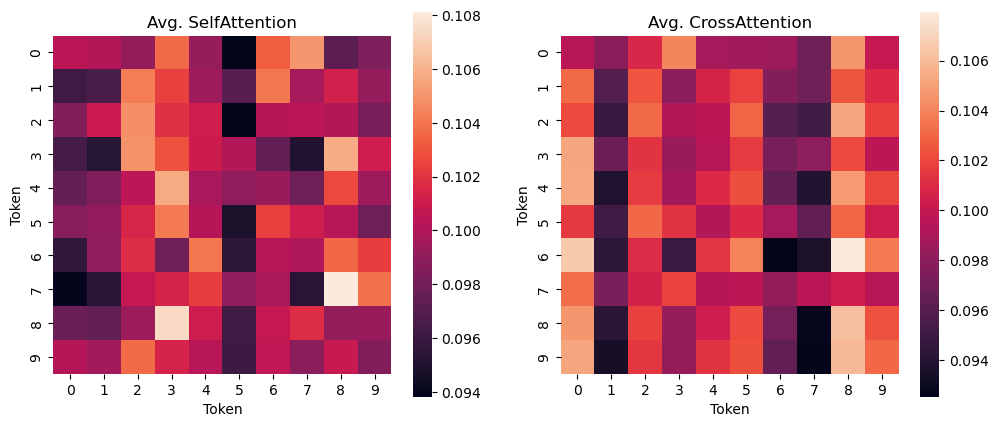

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.heatmap(avg_self.detach().numpy(), ax=ax[0])
ax[0].set_title('Avg. SelfAttention')
sns.heatmap(avg_cross.detach().numpy(), ax=ax[1])
ax[1].set_title('Avg. CrossAttention')

for i in range(2):
    ax[i].set_aspect('equal')
    ax[i].set_ylabel('Token')
    ax[i].set_xlabel('Token')

plt.show()

In [9]:
avg_cross

tensor([[0.0995, 0.0979, 0.1009, 0.1040, 0.0989, 0.0987, 0.0986, 0.0968, 0.1046,
         0.1001],
        [0.1031, 0.0958, 0.1024, 0.0979, 0.1007, 0.1019, 0.0977, 0.0970, 0.1025,
         0.1010],
        [0.1021, 0.0948, 0.1031, 0.0993, 0.0997, 0.1029, 0.0959, 0.0951, 0.1052,
         0.1018],
        [0.1052, 0.0968, 0.1014, 0.0984, 0.0995, 0.1016, 0.0972, 0.0980, 0.1022,
         0.0997],
        [0.1053, 0.0938, 0.1016, 0.0988, 0.1010, 0.1022, 0.0964, 0.0939, 0.1048,
         0.1020],
        [0.1016, 0.0952, 0.1030, 0.1013, 0.0993, 0.1010, 0.0989, 0.0965, 0.1029,
         0.1003],
        [0.1066, 0.0944, 0.1010, 0.0949, 0.1014, 0.1040, 0.0925, 0.0936, 0.1079,
         0.1037],
        [0.1032, 0.0973, 0.1006, 0.1019, 0.0994, 0.0997, 0.0983, 0.0996, 0.1004,
         0.0995],
        [0.1047, 0.0943, 0.1018, 0.0983, 0.1004, 0.1021, 0.0971, 0.0927, 0.1061,
         0.1024],
        [0.1052, 0.0935, 0.1015, 0.0982, 0.1014, 0.1023, 0.0964, 0.0926, 0.1059,
         0.1031]], grad_fn=<